<a href="https://colab.research.google.com/github/chuy-zip/COMPUTER_VISION_LAB10/blob/main/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: Comparación entre modelo estándar y modelo destilado en CPU/CUDA

### Integrantes

* Sergio Orellana 221122
* Rodrigo Mansilla 22611
* Ricardo Chuy 221007


## Prompt utilizado con IA y justificación

**Prompt utilizado:**

> Necesito ayuda para entender cómo resolver un laboratorio de modelos de difusión en Python. El objetivo es comparar un modelo estándar con un modelo más eficiente basado en destilación. Quiero saber cómo organizar el notebook, qué métricas conviene medir, cómo mostrar las imágenes generadas y cómo explicar técnicamente las diferencias entre ambos enfoques.

**Por qué funcionó:**

El prompt me funcionó porque no solicita únicamente código, sino una guía para estructurar la solución completa del laboratorio. En primer lugar, permite identificar los componentes principales del experimento: modelo estándar, modelo destilado, pasos de inferencia, semilla, prompt, tiempo de ejecución y uso de memoria. Además, ayuda a ordenar la visualización de resultados mediante imágenes lado a lado y una tabla comparativa.


## Instalación de dependencias


In [1]:
# Para Colab:
# !pip install -q -U diffusers transformers accelerate safetensors pillow matplotlib pandas ipywidgets


## Imports y configuración del entorno


In [2]:
%matplotlib inline

import gc
import os
import time
import threading

import psutil
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

from diffusers import StableDiffusionPipeline, AutoPipelineForText2Image


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
PREFER_CUDA = True
CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = "cuda" if PREFER_CUDA and CUDA_AVAILABLE else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32
SEED = 42

if PREFER_CUDA and not CUDA_AVAILABLE:
    print("PREFER_CUDA=True, pero PyTorch no detectó CUDA. Se usará CPU.")

PROMPT = "A highly detailed cinematic and futuristic fruit glowing in a cyberpunk laboratory, neon lights, 4k resolution"

HEIGHT = 512
WIDTH = 512

NUM_THREADS = min(os.cpu_count() or 1, 8)
torch.set_num_threads(NUM_THREADS)

os.makedirs("outputs_task2", exist_ok=True)

print("Dispositivo usado:", DEVICE)
print("Precisión usada:", DTYPE)
print("CUDA disponible:", CUDA_AVAILABLE)
print("Hilos de CPU usados por PyTorch:", torch.get_num_threads())
if DEVICE == "cuda":
    print("GPU usada:", torch.cuda.get_device_name(0))
print("Prompt:", PROMPT)
print("Seed:", SEED)


Dispositivo usado: cuda
Precisión usada: torch.float16
CUDA disponible: True
Hilos de CPU usados por PyTorch: 2
GPU usada: Tesla T4
Prompt: A highly detailed cinematic and futuristic fruit glowing in a cyberpunk laboratory, neon lights, 4k resolution
Seed: 42


## Funciones auxiliares para medir rendimiento en CPU o CUDA


In [4]:
class PeakRAMMonitor:
    def __init__(self, interval=0.05):
        self.interval = interval
        self.process = psutil.Process(os.getpid())
        self.peak_bytes = 0
        self._running = False
        self._thread = None

    def _watch(self):
        while self._running:
            rss = self.process.memory_info().rss
            if rss > self.peak_bytes:
                self.peak_bytes = rss
            time.sleep(self.interval)

    def start(self):
        self.peak_bytes = self.process.memory_info().rss
        self._running = True
        self._thread = threading.Thread(target=self._watch, daemon=True)
        self._thread.start()

    def stop(self):
        self._running = False
        if self._thread is not None:
            self._thread.join()
        self.peak_bytes = max(self.peak_bytes, self.process.memory_info().rss)

    @property
    def peak_mb(self):
        return self.peak_bytes / (1024 ** 2)

    @property
    def peak_gb(self):
        return self.peak_bytes / (1024 ** 3)


def using_cuda():
    return DEVICE == "cuda" and torch.cuda.is_available()


def limpiar_memoria():
    gc.collect()
    if using_cuda():
        torch.cuda.empty_cache()


def optimizar_pipeline(pipe):
    pipe = pipe.to(DEVICE)
    if hasattr(pipe, "enable_attention_slicing"):
        pipe.enable_attention_slicing()
    if hasattr(pipe, "enable_vae_slicing"):
        pipe.enable_vae_slicing()
    return pipe


def generar_y_medir(
    pipe,
    model_label,
    model_id,
    steps,
    output_path,
    guidance_scale=None,
):
    limpiar_memoria()

    generator = torch.Generator(device=DEVICE).manual_seed(SEED)

    kwargs = {
        "prompt": PROMPT,
        "num_inference_steps": steps,
        "generator": generator,
        "height": HEIGHT,
        "width": WIDTH,
    }

    if guidance_scale is not None:
        kwargs["guidance_scale"] = guidance_scale

    if using_cuda():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    monitor = PeakRAMMonitor()
    monitor.start()
    inicio = time.time()

    with torch.inference_mode():
        image = pipe(**kwargs).images[0]

    if using_cuda():
        torch.cuda.synchronize()

    fin = time.time()
    monitor.stop()

    tiempo_segundos = fin - inicio
    ram_mb = monitor.peak_mb
    ram_gb = monitor.peak_gb

    if using_cuda():
        vram_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
        vram_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)
    else:
        vram_mb = "N/A (CPU)"
        vram_gb = "N/A (CPU)"

    image.save(output_path)

    metricas = {
        "Modelo usado": model_label,
        "ID del modelo": model_id,
        "Dispositivo": DEVICE,
        "Precisión": str(DTYPE).replace("torch.", ""),
        "Pasos": steps,
        "Tiempo de Ejecución (s)": round(tiempo_segundos, 3),
        "VRAM (MB)": round(vram_mb, 2) if isinstance(vram_mb, float) else vram_mb,
        "VRAM (GB)": round(vram_gb, 3) if isinstance(vram_gb, float) else vram_gb,
        "RAM pico proceso (MB)": round(ram_mb, 2),
        "RAM pico proceso (GB)": round(ram_gb, 3),
        "Imagen guardada": output_path,
    }

    return image, metricas


# Escenario A: Modelo estándar - Costoso


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sd-legacy--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


  0%|          | 0/50 [00:00<?, ?it/s]

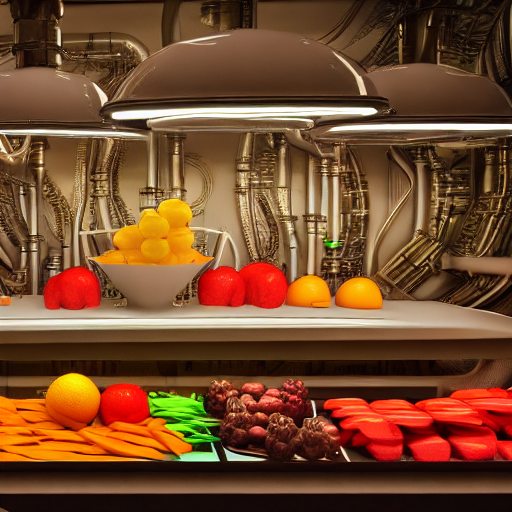

{'Modelo usado': 'Escenario A - Stable Diffusion v1.5',
 'ID del modelo': 'sd-legacy/stable-diffusion-v1-5',
 'Dispositivo': 'cuda',
 'Precisión': 'float16',
 'Pasos': 50,
 'Tiempo de Ejecución (s)': 11.568,
 'VRAM (MB)': 2676.41,
 'VRAM (GB)': 2.614,
 'RAM pico proceso (MB)': 3069.16,
 'RAM pico proceso (GB)': 2.997,
 'Imagen guardada': 'outputs_task2/escenario_A_sd15_50_steps.png'}

In [5]:
standard_model_id = "sd-legacy/stable-diffusion-v1-5"

pipe_a = StableDiffusionPipeline.from_pretrained(
    standard_model_id,
    torch_dtype=DTYPE,
    safety_checker=None,
    feature_extractor=None,
    requires_safety_checker=False,
)

pipe_a = optimizar_pipeline(pipe_a)

image_a, metrics_a = generar_y_medir(
    pipe=pipe_a,
    model_label="Escenario A - Stable Diffusion v1.5",
    model_id=standard_model_id,
    steps=50,
    output_path="outputs_task2/escenario_A_sd15_50_steps.png",
    guidance_scale=7.5,
)

display(image_a)
metrics_a


## Liberación de memoria entre modelos

Después de ejecutar el Escenario A, se elimina el pipeline de memoria. De este modo, la medición del Escenario B no queda contaminada por tensores o pesos del modelo anterior.


In [6]:
del pipe_a
limpiar_memoria()
print("Memoria RAM liberada antes de cargar el modelo destilado.")


Memoria RAM liberada antes de cargar el modelo destilado.


# Escenario B: Modelo destilado - Eficiente

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

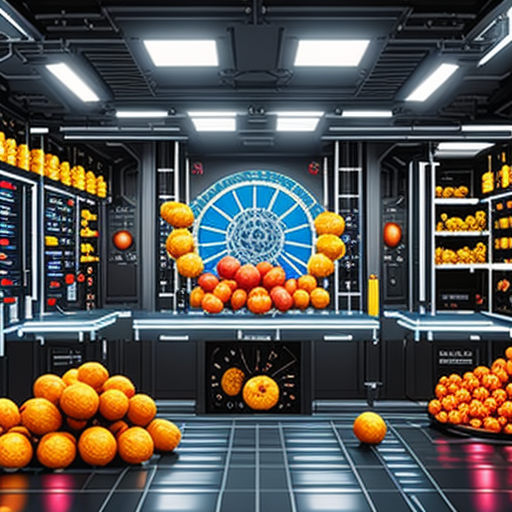

{'Modelo usado': 'Escenario B - SD-Turbo',
 'ID del modelo': 'stabilityai/sd-turbo',
 'Dispositivo': 'cuda',
 'Precisión': 'float16',
 'Pasos': 4,
 'Tiempo de Ejecución (s)': 1.053,
 'VRAM (MB)': 3099.61,
 'VRAM (GB)': 3.027,
 'RAM pico proceso (MB)': 4172.1,
 'RAM pico proceso (GB)': 4.074,
 'Imagen guardada': 'outputs_task2/escenario_B_sd_turbo_4_steps.png'}

In [7]:
turbo_model_id = "stabilityai/sd-turbo"

pipe_b = AutoPipelineForText2Image.from_pretrained(
    turbo_model_id,
    torch_dtype=DTYPE,
    safety_checker=None,
    feature_extractor=None,
    requires_safety_checker=False,
)

pipe_b = optimizar_pipeline(pipe_b)

image_b, metrics_b = generar_y_medir(
    pipe=pipe_b,
    model_label="Escenario B - SD-Turbo",
    model_id=turbo_model_id,
    steps=4,
    output_path="outputs_task2/escenario_B_sd_turbo_4_steps.png",
    guidance_scale=0.0,
)

display(image_b)
metrics_b


## Comparación visual lado a lado


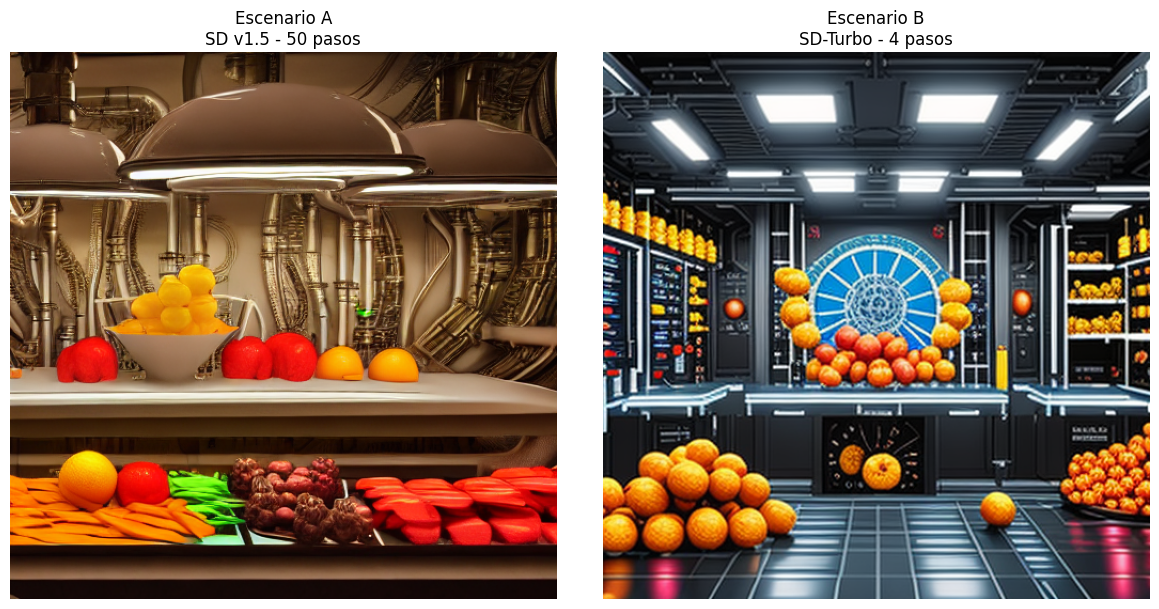

Imagen comparativa guardada en: outputs_task2/comparacion_lado_a_lado.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image_a)
axes[0].set_title("Escenario A\nSD v1.5 - 50 pasos")
axes[0].axis("off")

axes[1].imshow(image_b)
axes[1].set_title("Escenario B\nSD-Turbo - 4 pasos")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("outputs_task2/comparacion_lado_a_lado.png", dpi=150, bbox_inches="tight")
plt.show()

print("Imagen comparativa guardada en: outputs_task2/comparacion_lado_a_lado.png")


## Tabla comparativa de métricas


In [9]:
df_metricas = pd.DataFrame([metrics_a, metrics_b])
display(df_metricas)

df_metricas.to_csv("outputs_task2/tabla_metricas_task2.csv", index=False)
print("Tabla guardada en: outputs_task2/tabla_metricas_task2.csv")


,Modelo usado,ID del modelo,Dispositivo,Precisión,Pasos,Tiempo de Ejecución (s),VRAM (MB),VRAM (GB),RAM pico proceso (MB),RAM pico proceso (GB),Imagen guardada
0,Escenario A - Stable Diffusion v1.5,sd-legacy/stable-diffusion-v1-5,cuda,float16,50,11.568,2676.41,2.614,3069.16,2.997,outputs_task2/escenario_A_sd15_50_steps.png
1,Escenario B - SD-Turbo,stabilityai/sd-turbo,cuda,float16,4,1.053,3099.61,3.027,4172.10,4.074,outputs_task2/escenario_B_sd_turbo_4_steps.png


Tabla guardada en: outputs_task2/tabla_metricas_task2.csv


## Discusión técnica: destilación y pocos pasos

La diferencia principal entre ambos modelos está en la cantidad de pasos necesarios para transformar el tensor latente inicial en una imagen coherente. En un modelo estándar, la U-Net debe refinar el latente muchas veces. En cada paso, el modelo predice parte del ruido que debe removerse, el scheduler actualiza el estado del latente y, al final, el VAE decodifica ese latente para convertirlo en una imagen en píxeles. Por eso, al usar 50 pasos, Stable Diffusion v1.5 tiene más oportunidades para refinar detalles, corregir estructuras y mejorar texturas.

Por otra parte, SD-Turbo fue entrenado mediante destilación. Esto significa que el modelo aprende a aproximar en pocos pasos una trayectoria de denoising que normalmente requeriría muchos más. En otras palabras, no elimina el proceso de difusión, sino que lo comprime. Por esta razón, SD-Turbo puede generar una imagen coherente con solo 4 pasos, mientras que un modelo estándar configurado directamente con 4 pasos normalmente no tendría suficiente tiempo para limpiar el ruido y organizar correctamente la composición.

## Análisis de métricas

Los resultados obtenidos muestran una diferencia clara en tiempo de ejecución. Stable Diffusion v1.5 tardó 11.568 segundos con 50 pasos, mientras que SD-Turbo tardó 1.053 segundos con 4 pasos. Esto significa que el modelo destilado fue aproximadamente 10.99 veces más rápido. 

Sin embargo, la memoria no bajó en la misma proporción. Stable Diffusion v1.5 utilizó 2.614 GB de VRAM, mientras que SD-Turbo utilizó 3.027 GB. Es decir, SD-Turbo fue más rápido, pero consumió un poco más de VRAM. Esto es importante porque demuestra que la destilación no necesariamente hace que el modelo sea más pequeño en memoria. Más bien, su principal ventaja está en reducir la cantidad de evaluaciones de la U-Net durante el proceso de denoising.

También podemos observar que el tiempo promedio por paso no es necesariamente menor en SD-Turbo. Stable Diffusion v1.5 tardó aproximadamente 0.231 segundos por paso, mientras que SD-Turbo tardó aproximadamente 0.263 segundos por paso. Por tanto, la mejora no viene de que cada paso sea mucho más barato, sino de que el modelo necesita muchos menos pasos para llegar a una imagen visualmente coherente.

## Dictamen arquitectónico para producción

Con base en los resultados, elegiría el Escenario B, es decir, SD-Turbo a 4 pasos, como opción principal para una API de generación de imágenes con muchos usuarios. La razón principal es la reducción de tiempo: pasar de 11.568 segundos a 1.053 segundos por imagen cambia completamente la experiencia del usuario. En una aplicación real, una respuesta cercana a un segundo se siente mucho más interactiva que una respuesta de más de diez segundos.

No obstante, esta elección no significa que SD-Turbo sea mejor en todos los aspectos. El modelo estándar a 50 pasos puede producir imágenes con detalles más refinados, especialmente en texturas, brillos pequeños, bordes y elementos visuales finos. Por esa razón, Stable Diffusion v1.5 podría mantenerse como una opción de mayor calidad cuando el usuario esté dispuesto a esperar más tiempo.

En consecuencia, la mejor decisión arquitectónica sería usar SD-Turbo como modelo por defecto para producción, especialmente en escenarios donde importan la velocidad, la cantidad de solicitudes y la experiencia interactiva. Stable Diffusion v1.5 podría quedar como una alternativa de mayor fidelidad para casos donde la calidad visual final sea más importante que la latencia.

# Referencias 

GeeksforGeeks. (2026, May 9). What is Generative AI. https://www.geeksforgeeks.org/artificial-intelligence/what-is-generative-ai/

GeeksforGeeks. (2025, July 23). What is Stable Diffusion? Importance and Working. https://www.geeksforgeeks.org/artificial-intelligence/stable-diffusion/

GeeksforGeeks. (2025, December 16). Variational AutoEncoders. https://www.geeksforgeeks.org/machine-learning/variational-autoencoders/

GeeksforGeeks. (2026, April 1). Deep Learning Tutorial. https://www.geeksforgeeks.org/deep-learning/deep-learning-tutorial/